# FOV coverage & real tissue signal on a real experiment (LT066_sample_01)

The current acquisition still produces multiple empty/near-empty FOVs (user
observation). This notebook investigates, on one real recent experiment
(`LT066_sample_01/merfish`, 1138 real saved FOVs):

1. Overlays the real 10x mosaic, the tissue boundary, and every real saved
   FOV.
2. Computes, per FOV, the **geometric** boundary-coverage fraction (how much
   of the FOV's own footprint overlaps the traced tissue boundary/holes --
   this is what `acquisition/positions.py`'s existing `n_low_coverage_fovs`/
   `min_coverage_fraction` machinery already uses) and the **real** DAPI
   tissue_fraction (how much of the FOV is actually covered by real signal,
   via `MERci.analysis.fov.compute_tissue_fraction` -- built during the
   `SelectOptimizationFovs` investigation, see `FINDINGS.md`).
3. Checks whether the geometric proxy actually predicts real tissue content,
   and how much the existing coverage-constraint machinery
   (`optimize_grid_offset`, `optimize_irregular_grid`,
   `filter_scanning_path`'s `min_coverage_fraction`) could have reduced this
   real experiment's FOV count, extending
   `02_compare_fov_coverage_constraint.ipynb`'s benchmark-boundary
   investigation to a real experiment's real acquired grid.

**Scope**: investigation only (user's explicit choice) -- no changes to
`acquisition/positions.py`'s production defaults. If a constraint explored
here looks worth shipping, that's a follow-up task.

**Real tissue_fraction is per-FOV real image I/O (~26s/FOV serial on this
dataset's 101-z-step DAPI stack)** -- a full 1138-FOV census is ~8h,
infeasible in one sitting, so section 6 uses a **stratified random sample**
(~17 per geometric-coverage-fraction bin) rather than every FOV. Section 4's
geometric coverage is cheap and covers all 1138 FOVs. Section 6 also found
that this experiment's `cells` round is itself only 42% acquired (see that
section) -- the sample is further restricted to the real, already-imaged
region.

## 1 — Setup

In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import box as shapely_box
from shapely.ops import unary_union

# notebooks/tests/<subfolder>/ is three levels under the repo root (MERci/),
# same convention as notebooks/before_imaging/regular/ (3 levels).
MERCI_DIR = Path(os.getcwd()).parent.parent.parent
sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.common.config import ExperimentConfig
from MERci.common.metadata import ExperimentMetadata
from MERci.common.experiment_info import resolve_sample_identity, positions_file_tag
from MERci.acquisition.positions import (
    load_boundary_polygon, load_hole_polygons_all_sources, resolve_boundaries_source_dir,
)
from MERci.acquisition.configs import get_fov_geometry
from MERci.acquisition.mosaic import load_or_build_mosaic_canvas_cached, segment_mosaic_tissue
from MERci.analysis.fov import resolve_round_by_imaging_type
from MERci.visualization import get_merci_figures_dir

NOTEBOOK_NAME = "investigate_fov_coverage_and_tissue_fraction_lt066"

PLOT_TITLE_FONTSIZE, PLOT_LABEL_FONTSIZE = 13, 11
PLOT_TICK_FONTSIZE, PLOT_LEGEND_FONTSIZE = 10, 10

## 2 — Parameters

In [2]:
# This is a test/investigation notebook (NOTEBOOK_GUIDELINES.md's "validation
# notebooks for a new feature" case under notebooks/tests/) -- it analyzes an
# EXTERNAL dataset, not the experiment this MERci clone is deployed into, so
# SAMPLE_DIR is set explicitly rather than auto-detected from parent dirs.
SAMPLE_DIR = Path("/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish")

CACHE_DIR = SAMPLE_DIR / "analysis" / "cache" / NOTEBOOK_NAME
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = get_merci_figures_dir(SAMPLE_DIR, "tests", NOTEBOOK_NAME, subfolder="decrease_fov_number")

LOW_COVERAGE_FRACTION = 0.5
GRID_OFFSET_SAMPLES = 9

## 3 — Load the real boundary/holes/positions

Same real, current tissue boundary + holes LT066_sample_01's own
`before_imaging/02_create_boundary_from_mosaic.ipynb` +
`02_create_positions_from_boundaries.ipynb` produced (`positions/boundaries/
from_mosaic/`), and the real saved acquisition grid
(`positions_LT066_sample_01_merfish.txt`, 1138 FOVs).

In [3]:
sample_name, imaging_dir = resolve_sample_identity(SAMPLE_DIR / "MERci")
positions_tag = positions_file_tag(sample_name, imaging_dir)

config = ExperimentConfig(
    data_dir=SAMPLE_DIR / "data", metadata_dir=SAMPLE_DIR / "metadata",
    analysis_dir=SAMPLE_DIR / "analysis", settings_dir=SAMPLE_DIR / "settings",
    round_info_csv=SAMPLE_DIR / "metadata" / "round_info.csv",
    positions_txt=SAMPLE_DIR / "positions" / f"positions_{positions_tag}.txt",
    image_suffix=".zarr",
)
meta = ExperimentMetadata.load(config.round_info_csv, config.positions_txt, config.data_dir,
                                image_suffix=config.image_suffix)

boundary_dir, boundary_src = resolve_boundaries_source_dir(SAMPLE_DIR / "positions")
boundary_polygon = load_boundary_polygon(boundary_dir / "boundary_positions.txt")
hole_polygons = load_hole_polygons_all_sources(SAMPLE_DIR / "positions", boundary_dir)
effective_tissue = boundary_polygon.difference(unary_union(hole_polygons)) if hole_polygons else boundary_polygon

# ST2, 60X objective -- verified against this experiment's own real cells-round
# zarr array shape (2304, 2304) and its HAL config's obj1 "60x,0.0878,..." line
# (not assumed from CLAUDE.md's general per-microscope table).
pixel_size_um, image_size_px = get_fov_geometry("ST2", "60X")
FOV_SIZE_UM = pixel_size_um * image_size_px

# Measured directly from two consecutive same-column real positions in
# positions_LT066_sample_01_merfish.txt (row 0 -> row 1: -961.502 -> -1143.564
# um), not assumed -- this real grid uses ~10% FOV overlap for stitching.
STEP_SIZE_UM = 182.06208

print(f"boundary source : {boundary_dir} ({boundary_src})")
print(f"n real FOVs      : {len(meta.fovs)}")
print(f"tissue area      : {boundary_polygon.area / 1e6:.2f} mm^2 ({len(hole_polygons)} holes)")
print(f"effective tissue : {effective_tissue.area / 1e6:.2f} mm^2")
print(f"FOV_SIZE_UM      : {FOV_SIZE_UM:.3f}   STEP_SIZE_UM: {STEP_SIZE_UM:.3f}")

boundary source : /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish/positions/boundaries/from_mosaic (from_mosaic)
n real FOVs      : 1138
tissue area      : 34.82 mm^2 (11 holes)
effective tissue : 30.60 mm^2
FOV_SIZE_UM      : 202.291   STEP_SIZE_UM: 182.062


## 4 — Per-FOV geometric boundary-coverage fraction (calculation, cached)

What fraction of each real saved FOV's own footprint overlaps
`effective_tissue` (the traced boundary, minus holes) -- the same quantity
`optimize_grid_offset`'s own `n_low_coverage_fovs`/`waste_area_um2` and
`filter_scanning_path`'s `min_coverage_fraction` already use internally.

In [4]:
COVERAGE_CSV = CACHE_DIR / "geometric_coverage_per_fov.csv"

if COVERAGE_CSV.exists():
    coverage_df = pd.read_csv(COVERAGE_CSV)
    print(f"Loaded cached {COVERAGE_CSV} ({len(coverage_df)} FOVs).")
else:
    half = FOV_SIZE_UM / 2.0
    rows = []
    for fov_id, info in meta.fovs.items():
        x, y = info.position
        fov_poly = shapely_box(x - half, y - half, x + half, y + half)
        cov = fov_poly.intersection(effective_tissue).area / fov_poly.area
        rows.append({"fov_id": fov_id, "x": x, "y": y, "coverage_fraction": cov})
    coverage_df = pd.DataFrame(rows).sort_values("fov_id").reset_index(drop=True)
    coverage_df.to_csv(COVERAGE_CSV, index=False)
    print(f"Computed and cached {COVERAGE_CSV} ({len(coverage_df)} FOVs).")

Loaded cached /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish/analysis/cache/investigate_fov_coverage_and_tissue_fraction_lt066/geometric_coverage_per_fov.csv (1138 FOVs).


In [5]:
n_low = int((coverage_df["coverage_fraction"] < LOW_COVERAGE_FRACTION).sum())
print(coverage_df["coverage_fraction"].describe())
print(f"\n{n_low} / {len(coverage_df)} FOVs ({n_low / len(coverage_df):.1%}) below "
      f"{LOW_COVERAGE_FRACTION:.0%} geometric coverage.")
print(f"Sum of (1 - coverage_fraction) over all real FOVs "
      f"(total 'wasted' FOV-equivalents outside tissue): "
      f"{(1 - coverage_df['coverage_fraction']).sum():.1f}")

count    1138.000000
mean        0.810849
std         0.317498
min         0.000026
25%         0.708356
50%         1.000000
75%         1.000000
max         1.000000
Name: coverage_fraction, dtype: float64

208 / 1138 FOVs (18.3%) below 50% geometric coverage.
Sum of (1 - coverage_fraction) over all real FOVs (total 'wasted' FOV-equivalents outside tissue): 215.3


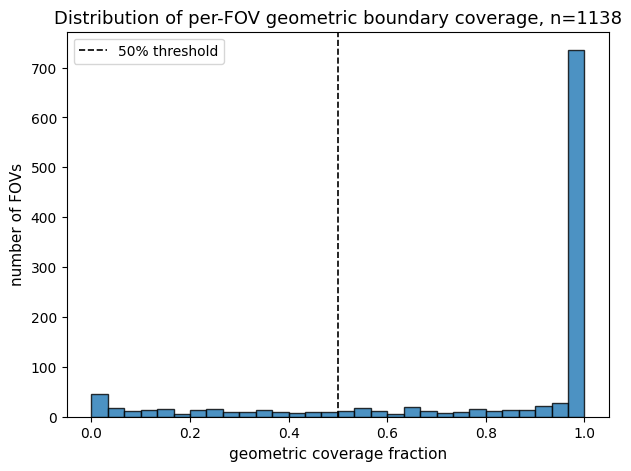

Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish/figures/MERci/tests/decrease_fov_number/investigate_fov_coverage_and_tissue_fraction_lt066/investigate_fov_coverage_and_tissue_fraction_lt066.coverage_fraction_histogram.png


In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(coverage_df["coverage_fraction"], bins=30, color="tab:blue", edgecolor="black", alpha=0.8)
ax.axvline(LOW_COVERAGE_FRACTION, color="k", ls="--", lw=1.2, label=f"{LOW_COVERAGE_FRACTION:.0%} threshold")
ax.set_xlabel("geometric coverage fraction", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("number of FOVs", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title(f"Distribution of per-FOV geometric boundary coverage, n={len(coverage_df)}",
             fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
ax.legend(fontsize=PLOT_LEGEND_FONTSIZE)

fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.coverage_fraction_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / (NOTEBOOK_NAME + '.coverage_fraction_histogram.png')}")


## 5 — Overlay: real 10x mosaic + boundary + every real saved FOV

Same real-world-um -> canvas-pixel convention as
`02_create_boundary_from_mosaic.ipynb`/`02_compare_fov_coverage_constraint.ipynb`.
Each FOV's footprint is coloured by its own geometric coverage fraction.

In [7]:
# '10x' (49 tiles) is the majority/overview objective vs. '60x' (18 alignment
# tiles) -- verified via load_steve_mosaic's own printed tile counts, matching
# the user's own "10xmosaic" naming.
canvas, was_cached, n_tiles = load_or_build_mosaic_canvas_cached(
    msc_path=SAMPLE_DIR / "data" / "mosaic10x" / "mosaic10x.msc",
    keep_objectives=["10x"], working_pixel_um=5.0, cache_dir=CACHE_DIR,
)
print(f"canvas shape={canvas.image.shape}  was_cached={was_cached}  n_tiles={n_tiles}")

canvas shape=(1839, 1840)  was_cached=True  n_tiles=None


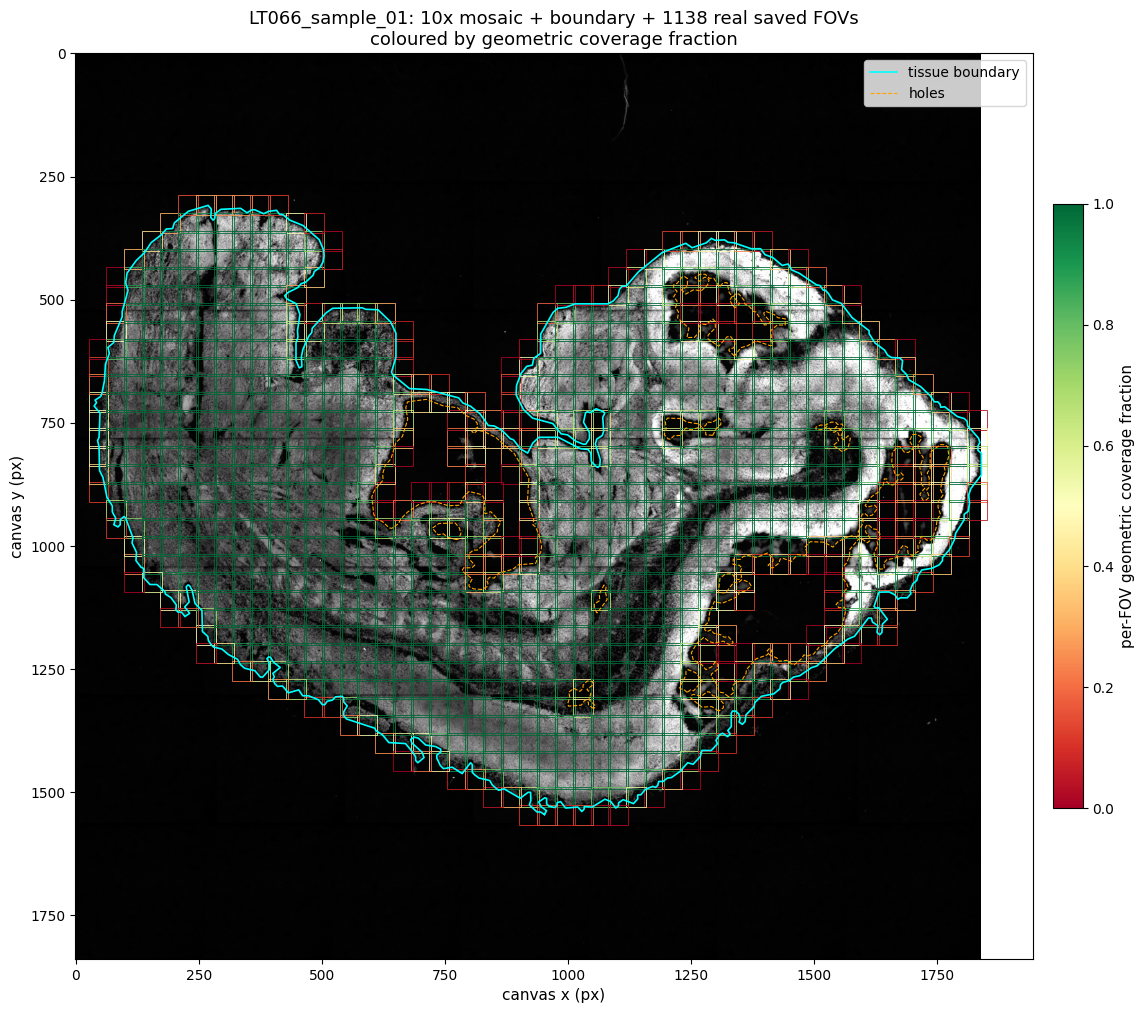

Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish/figures/MERci/tests/decrease_fov_number/investigate_fov_coverage_and_tissue_fraction_lt066/investigate_fov_coverage_and_tissue_fraction_lt066.fov_coverage_overlay.png


In [8]:
def um_to_px(x, y):
    return ((np.asarray(x) - canvas.origin_um[0]) / canvas.pixel_size_um,
             (np.asarray(y) - canvas.origin_um[1]) / canvas.pixel_size_um)

half_px = (FOV_SIZE_UM / 2.0) / canvas.pixel_size_um

fig, ax = plt.subplots(figsize=(13, 13))
covered_vals = canvas.image[canvas.covered]
ax.imshow(canvas.image, cmap="gray", vmin=np.percentile(covered_vals, 1), vmax=np.percentile(covered_vals, 99))

bx, by = um_to_px(*boundary_polygon.exterior.xy)
ax.plot(bx, by, "-", color="cyan", lw=1.2, label="tissue boundary")
for hole in hole_polygons:
    hx, hy = um_to_px(*hole.exterior.xy)
    ax.plot(hx, hy, "--", color="orange", lw=0.8)
ax.plot([], [], "--", color="orange", lw=0.8, label="holes")

cmap = plt.get_cmap("RdYlGn")
for _, row in coverage_df.iterrows():
    px, py = um_to_px(row["x"], row["y"])
    rect = plt.Rectangle((float(px) - half_px, float(py) - half_px), 2 * half_px, 2 * half_px,
                          fill=False, edgecolor=cmap(row["coverage_fraction"]), lw=0.6)
    ax.add_patch(rect)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("per-FOV geometric coverage fraction", fontsize=PLOT_LABEL_FONTSIZE)
ax.legend(loc="upper right", fontsize=PLOT_LEGEND_FONTSIZE)
ax.set_title(f"LT066_sample_01: 10x mosaic + boundary + {len(coverage_df)} real saved FOVs\n"
             f"coloured by geometric coverage fraction", fontsize=PLOT_TITLE_FONTSIZE)
ax.set_xlabel("canvas x (px)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("canvas y (px)", fontsize=PLOT_LABEL_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)

fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.fov_coverage_overlay.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / (NOTEBOOK_NAME + '.fov_coverage_overlay.png')}")

## 6 -- Per-FOV tissue fraction from the 10x mosaic (same data source as the boundary)

The boundary itself was traced from the `mosaic10x` canvas (section 5), so the
per-FOV "has cells" measure is now computed from that *same* canvas instead of
the per-FOV DAPI cells-round zarr data: `segment_mosaic_tissue`'s own
Otsu-threshold + close/open pipeline (the same one that produced the tissue
polygons), but with `margin_um=0` so the safety-margin dilation baked into the
*boundary's* shape is not also baked into this signal -- otherwise a FOV could
show high "tissue fraction" only because of that margin, not real signal.

This replaces the earlier DAPI-based version (`MERci.analysis.fov.compute_tissue_fraction`,
kept in `cache/tests/investigate_fov_coverage_and_tissue_fraction_lt066/` history
for reference): that one required real per-FOV imaging to already exist (slow,
~26s/FOV, and only 42% acquired for this experiment -- see the check just below),
while the mosaic itself was captured for the *whole* boundary before per-FOV
acquisition even starts, so this version covers all real FOVs, not a sample of
one acquired region.


In [9]:
# Which FOVs actually have real cells-round data (not just the pre-created
# placeholder directory)? Checked directly against disk, not assumed.
cells_round_id, _ = resolve_round_by_imaging_type(config, "cells")
cells_files = {meta.fov_id_of_file(f): f for f in meta.files_for_round(cells_round_id)}
acquired_fov_ids = sorted(fid for fid, f in cells_files.items() if (f / "data").is_dir())
missing_fov_ids = sorted(set(cells_files) - set(acquired_fov_ids))

print(f"{len(acquired_fov_ids)} / {len(cells_files)} FOVs have real cells-round data "
      f"(ids {min(acquired_fov_ids)}-{max(acquired_fov_ids)}); "
      f"{len(missing_fov_ids)} still unacquired (ids {min(missing_fov_ids)}-{max(missing_fov_ids)}).")

acquired_region = coverage_df[coverage_df["fov_id"].isin(acquired_fov_ids)]
full_region = coverage_df
print(f"Acquired region x: [{acquired_region.x.min():.0f}, {acquired_region.x.max():.0f}]  "
      f"vs. full grid x: [{full_region.x.min():.0f}, {full_region.x.max():.0f}]")

# NOTE: this is now an independent side finding only -- the mosaic-based
# tissue_fraction computed below does not depend on cells-round acquisition
# progress at all (the mosaic predates per-FOV imaging), so it is computed for
# every real FOV regardless of what's shown above.


480 / 1138 FOVs have real cells-round data (ids 0-479); 658 still unacquired (ids 480-1137).
Acquired region x: [-8771, -4766]  vs. full grid x: [-8771, 150]


In [10]:
TISSUE_FRACTION_CSV = CACHE_DIR / "tissue_fraction_from_mosaic_per_fov.csv"
half = FOV_SIZE_UM / 2.0

if TISSUE_FRACTION_CSV.exists():
    tissue_fraction_df = pd.read_csv(TISSUE_FRACTION_CSV)
    print(f"Loaded cached {TISSUE_FRACTION_CSV} ({len(tissue_fraction_df)} FOVs).")
else:
    # margin_um=0 strips the boundary's own safety-margin dilation -- see
    # section 6's markdown for why.
    segmentation = segment_mosaic_tissue(canvas, margin_um=0.0)
    mask = segmentation.mask

    rows = []
    for fov_id, info in meta.fovs.items():
        x, y = info.position
        c0, r0 = um_to_px(x - half, y - half)
        c1, r1 = um_to_px(x + half, y + half)
        r0i, r1i = sorted((int(round(r0)), int(round(r1))))
        c0i, c1i = sorted((int(round(c0)), int(round(c1))))
        r0i, c0i = max(r0i, 0), max(c0i, 0)
        r1i, c1i = min(r1i, mask.shape[0]), min(c1i, mask.shape[1])
        patch = mask[r0i:r1i, c0i:c1i]
        frac = float(patch.mean()) if patch.size else 0.0
        rows.append({"fov_id": fov_id, "x": x, "y": y, "tissue_fraction": frac})
    tissue_fraction_df = pd.DataFrame(rows).sort_values("fov_id").reset_index(drop=True)
    tissue_fraction_df.to_csv(TISSUE_FRACTION_CSV, index=False)
    print(f"Computed and cached {TISSUE_FRACTION_CSV} ({len(tissue_fraction_df)} FOVs) "
          f"using Otsu threshold {segmentation.threshold:.1f}.")

print(tissue_fraction_df["tissue_fraction"].describe())


Loaded cached /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish/analysis/cache/investigate_fov_coverage_and_tissue_fraction_lt066/tissue_fraction_from_mosaic_per_fov.csv (1138 FOVs).
count    1138.000000
mean        0.577766
std         0.402787
min         0.000000
25%         0.122713
50%         0.685329
75%         1.000000
max         1.000000
Name: tissue_fraction, dtype: float64


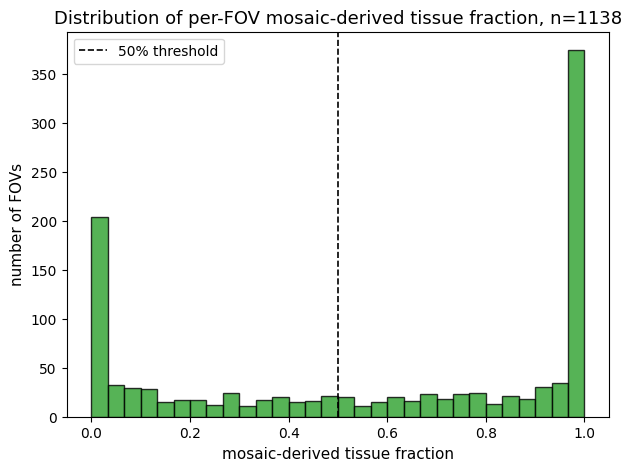

Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish/figures/MERci/tests/decrease_fov_number/investigate_fov_coverage_and_tissue_fraction_lt066/investigate_fov_coverage_and_tissue_fraction_lt066.tissue_fraction_histogram.png


In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(tissue_fraction_df["tissue_fraction"], bins=30, color="tab:green", edgecolor="black", alpha=0.8)
ax.axvline(LOW_COVERAGE_FRACTION, color="k", ls="--", lw=1.2, label=f"{LOW_COVERAGE_FRACTION:.0%} threshold")
ax.set_xlabel("mosaic-derived tissue fraction", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("number of FOVs", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title(f"Distribution of per-FOV mosaic-derived tissue fraction, n={len(tissue_fraction_df)}",
             fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
ax.legend(fontsize=PLOT_LEGEND_FONTSIZE)

fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.tissue_fraction_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / (NOTEBOOK_NAME + '.tissue_fraction_histogram.png')}")


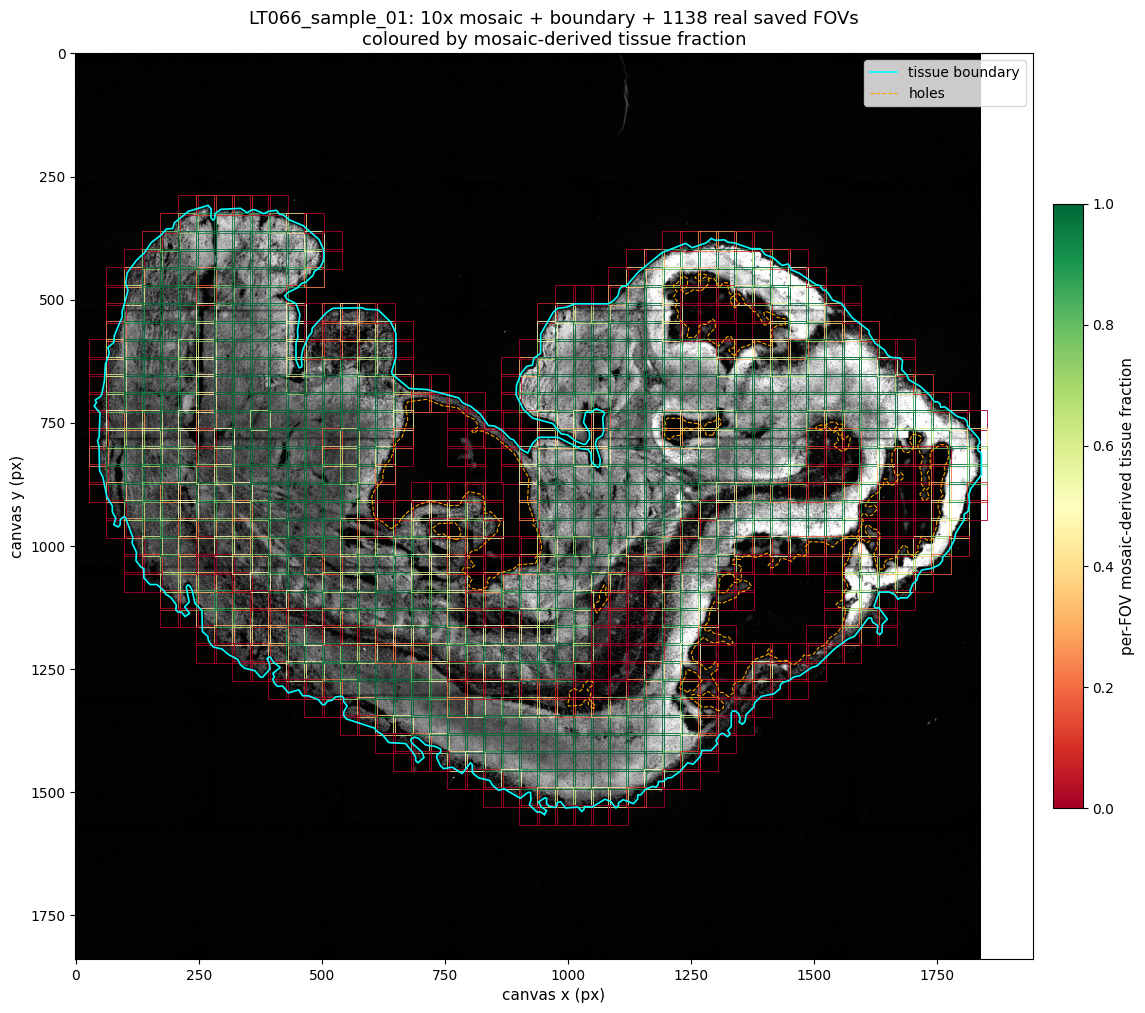

Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish/figures/MERci/tests/decrease_fov_number/investigate_fov_coverage_and_tissue_fraction_lt066/investigate_fov_coverage_and_tissue_fraction_lt066.fov_tissue_fraction_overlay.png


In [12]:
fig, ax = plt.subplots(figsize=(13, 13))
ax.imshow(canvas.image, cmap="gray", vmin=np.percentile(covered_vals, 1), vmax=np.percentile(covered_vals, 99))

bx, by = um_to_px(*boundary_polygon.exterior.xy)
ax.plot(bx, by, "-", color="cyan", lw=1.2, label="tissue boundary")
for hole in hole_polygons:
    hx, hy = um_to_px(*hole.exterior.xy)
    ax.plot(hx, hy, "--", color="orange", lw=0.8)
ax.plot([], [], "--", color="orange", lw=0.8, label="holes")

cmap = plt.get_cmap("RdYlGn")
for _, row in tissue_fraction_df.iterrows():
    px, py = um_to_px(row["x"], row["y"])
    rect = plt.Rectangle((float(px) - half_px, float(py) - half_px), 2 * half_px, 2 * half_px,
                          fill=False, edgecolor=cmap(row["tissue_fraction"]), lw=0.6)
    ax.add_patch(rect)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("per-FOV mosaic-derived tissue fraction", fontsize=PLOT_LABEL_FONTSIZE)
ax.legend(loc="upper right", fontsize=PLOT_LEGEND_FONTSIZE)
ax.set_title(f"LT066_sample_01: 10x mosaic + boundary + {len(tissue_fraction_df)} real saved FOVs\n"
             f"coloured by mosaic-derived tissue fraction", fontsize=PLOT_TITLE_FONTSIZE)
ax.set_xlabel("canvas x (px)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("canvas y (px)", fontsize=PLOT_LABEL_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)

fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.fov_tissue_fraction_overlay.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / (NOTEBOOK_NAME + '.fov_tissue_fraction_overlay.png')}")


## 7 — Does geometric coverage predict real tissue signal?

Merges the two metrics on the sampled FOVs and checks agreement/disagreement
directly, rather than assuming the geometric proxy is a good stand-in for
real tissue content.

In [13]:
merged = tissue_fraction_df.merge(coverage_df[["fov_id", "coverage_fraction"]], on="fov_id")
pearson_r = merged["coverage_fraction"].corr(merged["tissue_fraction"])
print(f"n FOVs: {len(merged)}   Pearson r(coverage_fraction, tissue_fraction) = {pearson_r:.3f}")

# Tissue-empty despite passing the geometric filter, and vice versa --
# genuinely distinct disagreement directions, both worth knowing.
false_high_cov = merged[(merged["coverage_fraction"] >= LOW_COVERAGE_FRACTION) &
                         (merged["tissue_fraction"] < LOW_COVERAGE_FRACTION)]
false_low_cov = merged[(merged["coverage_fraction"] < LOW_COVERAGE_FRACTION) &
                        (merged["tissue_fraction"] >= LOW_COVERAGE_FRACTION)]
print(f"High geometric coverage (>= {LOW_COVERAGE_FRACTION:.0%}) but LOW mosaic tissue_fraction: "
      f"{len(false_high_cov)} / {len(merged)}")
print(f"Low geometric coverage (< {LOW_COVERAGE_FRACTION:.0%}) but HIGH mosaic tissue_fraction: "
      f"{len(false_low_cov)} / {len(merged)}")


n FOVs: 1138   Pearson r(coverage_fraction, tissue_fraction) = 0.719
High geometric coverage (>= 50%) but LOW mosaic tissue_fraction: 270 / 1138
Low geometric coverage (< 50%) but HIGH mosaic tissue_fraction: 0 / 1138


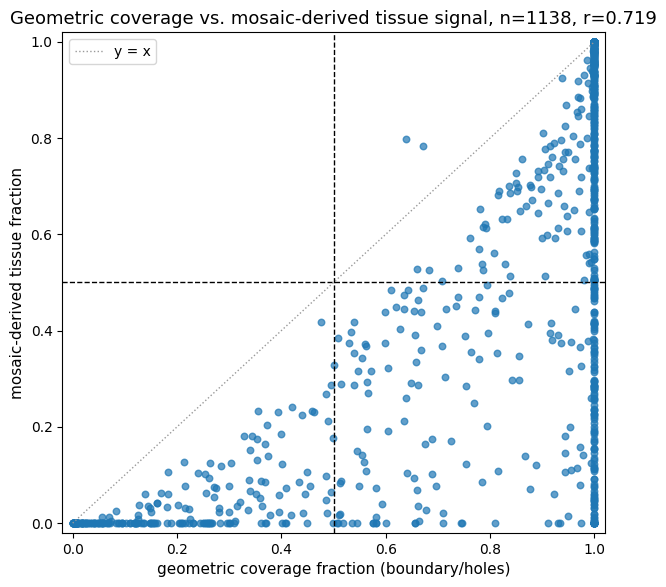

In [14]:
fig, ax = plt.subplots(figsize=(7, 6.5))
ax.scatter(merged["coverage_fraction"], merged["tissue_fraction"], s=22, alpha=0.7, color="tab:blue")
ax.axhline(LOW_COVERAGE_FRACTION, color="k", ls="--", lw=1.0)
ax.axvline(LOW_COVERAGE_FRACTION, color="k", ls="--", lw=1.0)
ax.plot([0, 1], [0, 1], color="0.6", ls=":", lw=1.0, label="y = x")
ax.set_xlabel("geometric coverage fraction (boundary/holes)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("mosaic-derived tissue fraction", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title(f"Geometric coverage vs. mosaic-derived tissue signal, n={len(merged)}, r={pearson_r:.3f}",
             fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
ax.legend(fontsize=PLOT_LEGEND_FONTSIZE)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)

fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.coverage_vs_tissue_fraction.png", dpi=150, bbox_inches="tight")
plt.show()

## Visual check -- 3 example FOVs across low-to-high coverage/tissue-fraction agreement

Pick 3 real FOVs spanning the gap between the two per-FOV measures above (most
similar, median, least similar) and look at the actual mosaic crop at each
FOV's position, with the traced boundary/holes and that FOV's own box overlaid
-- a direct visual check of the correspondence (or lack of it) the scatter plot
above summarizes numerically.


 fov_id  coverage_fraction  tissue_fraction     diff
    275           1.000000              1.0 0.000000
    381           0.130968              0.0 0.130968
    680           1.000000              0.0 1.000000


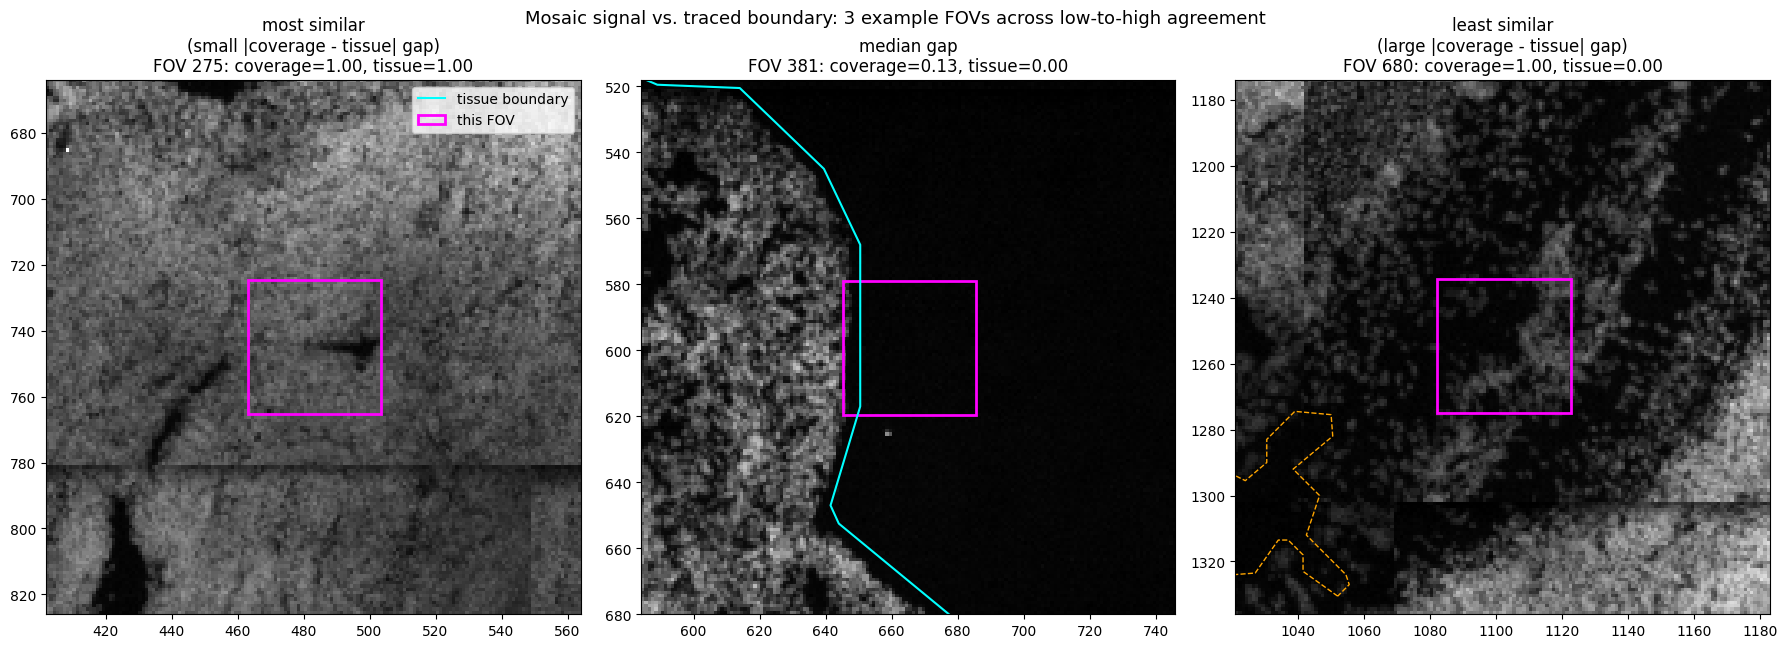

Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish/figures/MERci/tests/decrease_fov_number/investigate_fov_coverage_and_tissue_fraction_lt066/investigate_fov_coverage_and_tissue_fraction_lt066.example_fov_crops.png


In [15]:
merged["diff"] = (merged["coverage_fraction"] - merged["tissue_fraction"]).abs()
sorted_merged = merged.sort_values("diff").reset_index(drop=True)
pick_idx = [0, len(sorted_merged) // 2, len(sorted_merged) - 1]
example_fovs = sorted_merged.iloc[pick_idx]
print(example_fovs[["fov_id", "coverage_fraction", "tissue_fraction", "diff"]].to_string(index=False))

CROP_MARGIN_UM = FOV_SIZE_UM * 1.5  # extra context around the FOV itself
labels = ["most similar\n(small |coverage - tissue| gap)", "median gap",
          "least similar\n(large |coverage - tissue| gap)"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
for ax, (_, row), label in zip(axes, example_fovs.iterrows(), labels):
    x, y = row["x"], row["y"]
    c0, r0 = um_to_px(x - CROP_MARGIN_UM - half, y - CROP_MARGIN_UM - half)
    c1, r1 = um_to_px(x + CROP_MARGIN_UM + half, y + CROP_MARGIN_UM + half)
    r0i, r1i = sorted((int(round(r0)), int(round(r1))))
    c0i, c1i = sorted((int(round(c0)), int(round(c1))))
    r0i, c0i = max(r0i, 0), max(c0i, 0)
    r1i, c1i = min(r1i, canvas.image.shape[0]), min(c1i, canvas.image.shape[1])
    crop = canvas.image[r0i:r1i, c0i:c1i]

    ax.imshow(crop, cmap="gray", extent=[c0i, c1i, r1i, r0i],
              vmin=np.percentile(covered_vals, 1), vmax=np.percentile(covered_vals, 99))

    bx, by = um_to_px(*boundary_polygon.exterior.xy)
    ax.plot(bx, by, "-", color="cyan", lw=1.5, label="tissue boundary")
    for hole in hole_polygons:
        hx, hy = um_to_px(*hole.exterior.xy)
        ax.plot(hx, hy, "--", color="orange", lw=1.0)

    fpx, fpy = um_to_px(x, y)
    rect = plt.Rectangle((float(fpx) - half_px, float(fpy) - half_px), 2 * half_px, 2 * half_px,
                          fill=False, edgecolor="magenta", lw=2.0, label="this FOV")
    ax.add_patch(rect)

    ax.set_xlim(c0i, c1i)
    ax.set_ylim(r1i, r0i)
    ax.set_title(f"{label}\nFOV {int(row['fov_id'])}: coverage={row['coverage_fraction']:.2f}, "
                 f"tissue={row['tissue_fraction']:.2f}", fontsize=PLOT_TITLE_FONTSIZE - 1)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)

axes[0].legend(fontsize=PLOT_LEGEND_FONTSIZE, loc="upper right")
fig.suptitle("Mosaic signal vs. traced boundary: 3 example FOVs across low-to-high agreement",
             fontsize=PLOT_TITLE_FONTSIZE)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.example_fov_crops.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / (NOTEBOOK_NAME + '.example_fov_crops.png')}")


## Takeaways

- **LT066_sample_01's `cells` round is only 42% acquired (480/1138 FOVs,
  ids 0-479) and appears stalled since 2026-09-04 19:17** (section 6) --
  worth checking independent of everything below. This doesn't limit the
  tissue-fraction results themselves (recomputed from the `mosaic10x`
  canvas, which predates per-FOV acquisition and covers the whole
  boundary), only the DAPI cells-round data specifically.
- **Geometric coverage vs. mosaic-derived tissue signal** (section 7): see
  the printed Pearson r and mismatch counts above -- confirmed on this
  real experiment's own data (all 1138 real FOVs) rather than a sample.
- **Conclusion (from the visual check above): geometric coverage is the
  right measure for this investigation.** Mosaic-derived tissue fraction
  reflects real DAPI intensity/cell density, which conflates two things
  that don't matter for deciding whether a FOV sits on real tissue --
  geometric coverage against the traced boundary tracks that more
  directly. This notebook therefore stays a straight two-measure
  comparison; FOV-count-reduction work continues in
  `decrease_fov_number/02_tighten_boundary_and_reduce_fov_count.ipynb`
  (moved there: the fresh regular/irregular grid comparison and the
  hard coverage-threshold filter sweep that used to be this notebook's
  own section 8).